# Day 04：顺序的秘密 —— 位置编码，让注意力知道"谁在哪儿"> 🚀 第十一周 · 注意力时代 · 第 4 天注意力机制有一个"缺陷"：**它天生不知道顺序。**RNN 按顺序处理输入，天然知道"谁在前面，谁在后面"。但注意力是"一次性看全部"——它把所有词当成一个集合，而不是一个序列。> "猫吃鱼" vs "鱼吃猫"对注意力来说，这两个句子的词是一样的（集合相同），但意思完全不同（顺序不同）。解决方案：**位置编码（Positional Encoding）**——给每个位置加上一个"位置标签"。**今天的任务**：1. 理解为什么注意力需要位置编码2. 学习正弦位置编码的数学原理3. 用代码实现并可视化位置编码---

## 1. 历史剧场：Transformer 的"顺序补丁"2017 年 Transformer 论文中，Vaswani 等人用正弦/余弦函数生成位置编码：$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$这个设计有两个巧妙之处：1. 每个位置有唯一的编码2. 相对位置关系可以通过编码的线性变换得到---

## 2. 生活隐喻：座次牌想象一个会议室：- **没有座次牌**：大家随便坐，你不知道谁坐在第几个位置- **有座次牌**：每个座位上写着"1号位"、"2号位"……你知道每个人的位置位置编码就是给每个词发一个"座次牌"——让注意力知道每个词在序列中的位置。但座次牌不是简单的 1, 2, 3... 因为那样不同位置之间的差异不均匀（1和2的差异 = 2和3的差异，但 100和101的差异相对更小）。正弦编码用不同频率的正弦波，让每个位置有独特的"指纹"。---

<p align="center">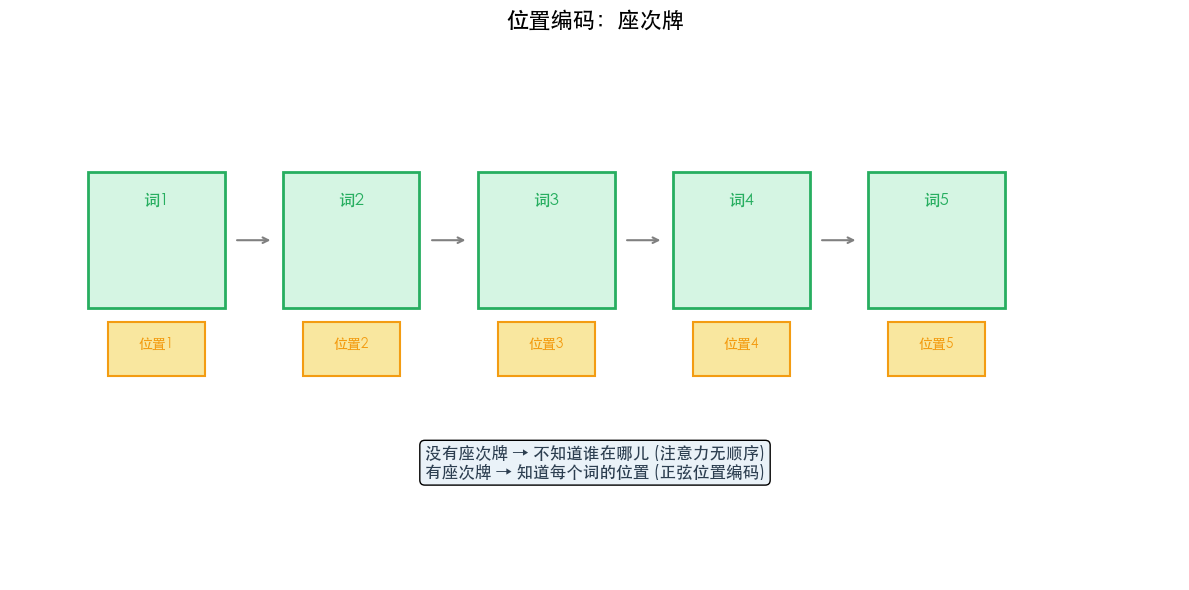</p>*位置编码座次牌示意图*

## 3. 数学直觉：正弦位置编码### 3.1 为什么用正弦波？不同维度使用不同频率的正弦/余弦波：- **低频维度**（i 小）：变化缓慢，区分远距离位置- **高频维度**（i 大）：变化快速，区分近距离位置就像一个"位置条形码"：不同维度的条纹粗细不同，组合起来唯一标识每个位置。### 3.2 为什么能表示相对位置？对于任意固定偏移 $k$，$PE_{pos+k}$ 可以表示为 $PE_{pos}$ 的线性函数：$$PE_{pos+k} = M_k \cdot PE_{pos}$$其中 $M_k$ 是一个旋转矩阵。这意味着模型可以通过学习线性变换来捕捉相对位置关系。---

## 4. 代码实验室：手写位置编码

In [ ]:
import torchimport torch.nn as nnimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 4.1 手写正弦位置编码

In [ ]:
def positional_encoding(seq_len, d_model):    PE = np.zeros((seq_len, d_model))    position = np.arange(seq_len)[:, np.newaxis]    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))    PE[:, 0::2] = np.sin(position * div_term)    PE[:, 1::2] = np.cos(position * div_term)    return PEseq_len = 50d_model = 64PE = positional_encoding(seq_len, d_model)print(f"位置编码形状: {PE.shape}")print(f"位置 0 的前8维: {PE[0, :8].round(3)}")print(f"位置 1 的前8维: {PE[1, :8].round(3)}")

### 4.2 可视化位置编码

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))im = axes[0].imshow(PE, aspect='auto', cmap='RdBu_r')axes[0].set_xlabel('维度', fontsize=12)axes[0].set_ylabel('位置', fontsize=12)axes[0].set_title('位置编码热力图', fontsize=14)plt.colorbar(im, ax=axes[0])dims_to_plot = [0, 1, 10, 11, 30, 31]for d in dims_to_plot:    label = f'维度{d} ({"sin" if d%2==0 else "cos"})'    axes[1].plot(PE[:, d], label=label, alpha=0.8)axes[1].set_xlabel('位置', fontsize=12)axes[1].set_ylabel('编码值', fontsize=12)axes[1].set_title('不同维度的正弦波', fontsize=14)axes[1].legend(fontsize=9)axes[1].grid(True, alpha=0.3)sim_matrix = PE @ PE.Tnorms = np.linalg.norm(PE, axis=1, keepdims=True)cos_sim = sim_matrix / (norms @ norms.T)im = axes[2].imshow(cos_sim, cmap='RdBu_r', vmin=-1, vmax=1)axes[2].set_xlabel('位置', fontsize=12)axes[2].set_ylabel('位置', fontsize=12)axes[2].set_title('位置编码的余弦相似度', fontsize=14)plt.colorbar(im, ax=axes[2])plt.tight_layout()plt.show()

### 解读- **热力图**：不同位置有不同的"条形码"模式- **正弦波**：低频维度变化慢，高频维度变化快- **余弦相似度**：对角线最亮（自己和自己的相似度=1），近邻位置相似度较高---

## 5. 位置编码如何加入输入

In [ ]:
np.random.seed(42)X = np.random.randn(seq_len, d_model) * 0.1X_with_pos = X + PEprint("位置编码如何加入输入：")print(f"原始输入 X: 均值={X.mean():.4f}, 标准差={X.std():.4f}")print(f"位置编码 PE: 均值={PE.mean():.4f}, 标准差={PE.std():.4f}")print(f"加入后 X+PE: 均值={X_with_pos.mean():.4f}, 标准差={X_with_pos.std():.4f}")print()print("关键: 位置编码是加到词嵌入上的，不是拼接")print("      这让模型能同时获取语义信息和位置信息")

### 5.2 验证：没有位置编码，注意力分不清顺序

In [ ]:
def attention_similarity(X1, X2):    sim = X1 @ X2.T    norms1 = np.linalg.norm(X1, axis=1, keepdims=True)    norms2 = np.linalg.norm(X2, axis=1, keepdims=True)    return sim / (norms1 @ norms2.T)np.random.seed(42)seq = np.random.randn(5, d_model) * 0.1seq_reversed = seq[::-1]sim_no_pos = attention_similarity(seq, seq_reversed)seq_with_pos = seq + PE[:5]seq_rev_with_pos = seq_reversed + PE[:5]sim_with_pos = attention_similarity(seq_with_pos, seq_rev_with_pos)print("没有位置编码时，正序和逆序的相似度:")print(np.round(sim_no_pos, 2))print()print("有位置编码时，正序和逆序的相似度:")print(np.round(sim_with_pos, 2))print()print("结论: 位置编码让模型能区分不同的顺序")

---

## 今日结语位置编码是 Transformer 的"顺序补丁"——它让注意力机制知道每个词的位置。正弦位置编码用不同频率的正弦波为每个位置生成唯一的"指纹"，通过加法融入词嵌入。这样模型既能获取语义信息，又能获取位置信息。明天，我们将把注意力、多头注意力和位置编码组合起来，搭建 Transformer 的核心：编码器。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 座次牌——标注谁坐哪里 | 位置编码——标注每个词的位置 || 位置条形码 | 正弦/余弦编码——不同频率组合唯一标识 || 低频区分远距离，高频区分近距离 | 不同维度的正弦波频率不同 || 把座次牌放在座位上 | 位置编码加到词嵌入上 || 没有座次牌就不知道谁在哪儿 | 没有位置编码，注意力不知道顺序 |